# 00 — Inventário, normalização e controles

**O que este notebook estabelece, e sem o que nada depois é interpretável:**

1. o **manifesto** — pareamento materializado, nunca `sorted()` de dois diretórios;
2. o **QC por par** — nada é excluído, tudo vira flag;
3. as **constantes globais** (σ do ruído, limiar de gradiente, limites da GLCM),
   derivadas do conjunto REAL e aplicadas identicamente a todos os conjuntos;
4. os **conjuntos de controle**, que são o que dá às métricas o direito de opinar.

## Por que existem quatro controles e não um

Uma métrica que não separa o real de uma imagem **sabidamente ruim** é cega, e o
número dela não valida nada. Mas "ruim" tem direção:

| conjunto | degradação | responde |
|---|---|---|
| `bicubic_2`, `bicubic_4` | suavização (perda de alta frequência) | a métrica vê borrão? |
| `real_noise` | excesso de alta frequência sem estrutura | a métrica vê ruído injetado? |
| `real_q1` × `real_q2` | nenhuma — mesmo tecido | qual é o piso de ruído da métrica? |

O plano original tinha só o bicúbico. Os dados mostraram que o sintético falha na
direção **oposta** à do bicúbico (excesso, não falta, de alta frequência), então um
controle só de suavização deixaria quase toda métrica passar de graça.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from texture import io as tio, pipeline, spectrum as tspec  # noqa: E402
from texture.store import Config  # noqa: E402

cfg = Config(ROOT / "config.yaml")
print("saída:", cfg.out)

saída: /Users/bringel/ARIA/UPenn/avaliacao-de-mamografias-sinteticas/outputs/gen-fid


## 1. Manifesto e QC

Roda a extração completa (225 pares, ~1 min). Idempotente: re-executar com a mesma
configuração substitui as linhas, não duplica.

In [2]:
man = pipeline.run_inventory(cfg)
man.head()

  25/225 pares


  50/225 pares


  75/225 pares


  100/225 pares


  125/225 pares


...

  175/225 pares


  200/225 pares


  225/225 pares



225 pares | σ ruído 0.01259 | limiar grad 0.09572 | GLCM [0.0000, 0.8228]
corr mediana 0.933 | afim a mediana 0.414 | harm 4px syn mediana 0.47 decadas


,pair_id,real_path,syn_path,batch,abnormality,split,patient_id,image_id,laterality,view,roi_index
0,0_Calc-Test_P_00038_LEFT_MLO_1,/Users/bringel/ARIA/UPenn/avaliacao-de-mamogra...,/Users/bringel/ARIA/UPenn/avaliacao-de-mamogra...,0,Calc,Test,P_00038,P_00038_LEFT_MLO,LEFT,MLO,1
1,0_Calc-Test_P_00246_RIGHT_MLO_1,/Users/bringel/ARIA/UPenn/avaliacao-de-mamogra...,/Users/bringel/ARIA/UPenn/avaliacao-de-mamogra...,0,Calc,Test,P_00246,P_00246_RIGHT_MLO,RIGHT,MLO,1
2,0_Calc-Test_P_00315_LEFT_MLO_1,/Users/bringel/ARIA/UPenn/avaliacao-de-mamogra...,/Users/bringel/ARIA/UPenn/avaliacao-de-mamogra...,0,Calc,Test,P_00315,P_00315_LEFT_MLO,LEFT,MLO,1
3,0_Calc-Test_P_00331_LEFT_MLO_1,/Users/bringel/ARIA/UPenn/avaliacao-de-mamogra...,/Users/bringel/ARIA/UPenn/avaliacao-de-mamogra...,0,Calc,Test,P_00331,P_00331_LEFT_MLO,LEFT,MLO,1
4,0_Calc-Test_P_00344_LEFT_MLO_1,/Users/bringel/ARIA/UPenn/avaliacao-de-mamogra...,/Users/bringel/ARIA/UPenn/avaliacao-de-mamogra...,0,Calc,Test,P_00344,P_00344_LEFT_MLO,LEFT,MLO,1


## 2. Estrutura do dataset

A pergunta "a consistência é parecida **entre os conjuntos**" exige saber quais
conjuntos existem. Note que há mais pares que pacientes: 6 imagens contribuem com
mais de uma ROI, então bootstrap e testes agrupam por `patient_id`.

In [3]:
print(f"{len(man)} pares | {man.patient_id.nunique()} pacientes | {man.image_id.nunique()} imagens")
for col in ["batch", "abnormality", "split", "view"]:
    print(f"  {col:12s}", man[col].value_counts().to_dict())

225 pares | 202 pacientes | 218 imagens
  batch        {0: 97, 2: 79, 1: 49}
  abnormality  {'Mass': 123, 'Calc': 102}
  split        {'Training': 163, 'Test': 62}
  view         {'MLO': 128, 'CC': 97}


In [4]:
qc = pd.read_parquet(cfg.out / "qc.parquet").pivot_table(index="pair_id", columns="flag", values="value")
qc = qc.join(man.set_index("pair_id")[["batch", "abnormality", "split", "patient_id"]])
qc.describe().T[["mean", "50%", "min", "max"]].round(4)

,mean,50%,min,max
affine_a,0.4456,0.4139,0.1346,1.2255
affine_a_ls,0.4027,0.3808,0.1104,1.1221
affine_b,0.2898,0.3180,-0.5053,0.5894
affine_b_ls,0.3116,0.3359,-0.4305,0.5950
affine_method_moment,1.0000,1.0000,1.0000,1.0000
affine_resid_std,0.0285,0.0262,0.0127,0.0789
corr,0.9085,0.9335,0.1398,0.9901
distinct_real,1567.3956,1299.0000,559.0000,15245.0000
distinct_syn,245205.7111,247367.0000,216615.0000,257876.0000
harmonic_4px_real,0.8317,0.5480,-0.1387,2.4094


## 3. O que o QC revela

### 3.1 O sintético não está na escala do real

`syn ≈ a·real + b` com **a ≈ 0,38**: o modelo devolve a imagem com a faixa dinâmica
comprimida a ~40 %. O mapeamento é linear (resíduo pequeno), então um alinhamento
afim por par corrige — mas se não corrigisse, GLCM com bins globais, SSIM, PSNR e
gradiente estariam medindo **offset de intensidade**, não textura.

### 3.2 O real é 12 bits; o sintético é float contínuo

O real vive na grade 1/4095 (~1 300 valores distintos por ROI); o sintético tem
~247 000 (quase todo pixel único). LBP, GLCM e estatística de gradiente são
sensíveis à estrutura de **empates**: sem requantizar o sintético na grade do real,
eles separariam os conjuntos pela quantização e não pela textura.

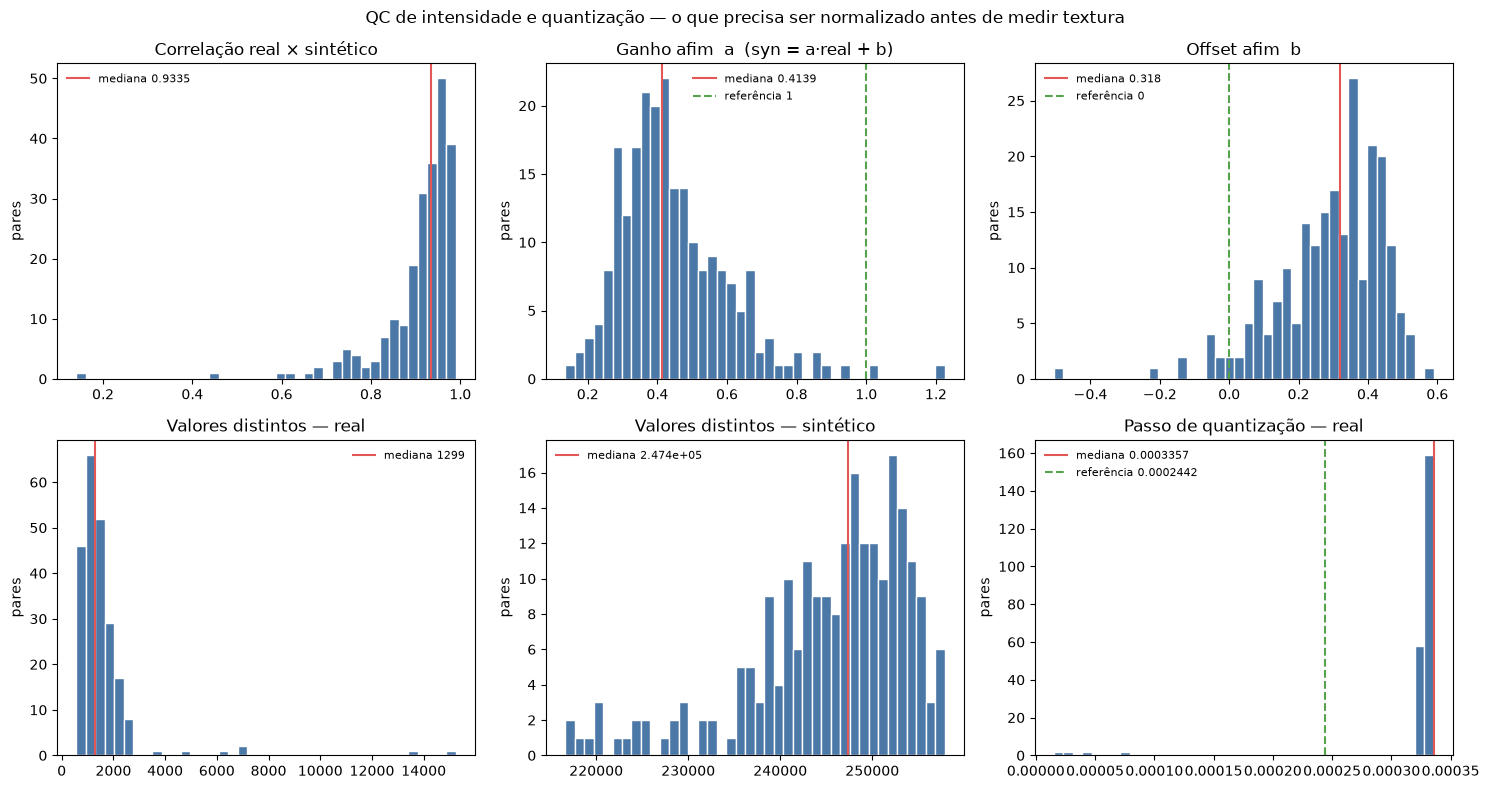

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
panels = [
    ("corr", "Correlação real × sintético", None),
    ("affine_a", "Ganho afim  a  (syn = a·real + b)", 1.0),
    ("affine_b", "Offset afim  b", 0.0),
    ("distinct_real", "Valores distintos — real", None),
    ("distinct_syn", "Valores distintos — sintético", None),
    ("value_step_real", "Passo de quantização — real", 1 / 4095),
]
for ax, (col, title, ref) in zip(axes.ravel(), panels):
    ax.hist(qc[col].dropna(), bins=40, color="#4C78A8", edgecolor="white")
    ax.axvline(qc[col].median(), color="#E45756", label=f"mediana {qc[col].median():.4g}")
    if ref is not None:
        ax.axvline(ref, color="#54A24B", ls="--", label=f"referência {ref:.4g}")
    ax.set(title=title, ylabel="pares")
    ax.legend(frameon=False, fontsize=8)
fig.suptitle("QC de intensidade e quantização — o que precisa ser normalizado antes de medir textura")
fig.tight_layout()

### 3.3 O artefato periódico: alternância de 2 px, não grade de 4 px

O sintético carrega uma assinatura de **período 2 px** (pico em Nyquist do perfil de
|gradiente|) — a marca de upsampling 2× por convolução transposta / pixel-shuffle.
Ela separa real de sintético **perfeitamente** (AUC 1,0), e é **artefato de geração,
não textura de tecido**. Por isso é medida sob nome próprio (`nyquist_excess`) e a
pergunta de textura é respondida também na banda passa-baixa, onde ela não alcança.

O harmônico de período 8 px é blocagem **JPEG no conjunto real** (CBIS-DDSM
distribuído comprimido): ~25 % das ROIs reais acima de 1,5 decadas. Fica como flag e
entra na análise de sensibilidade do notebook 03.

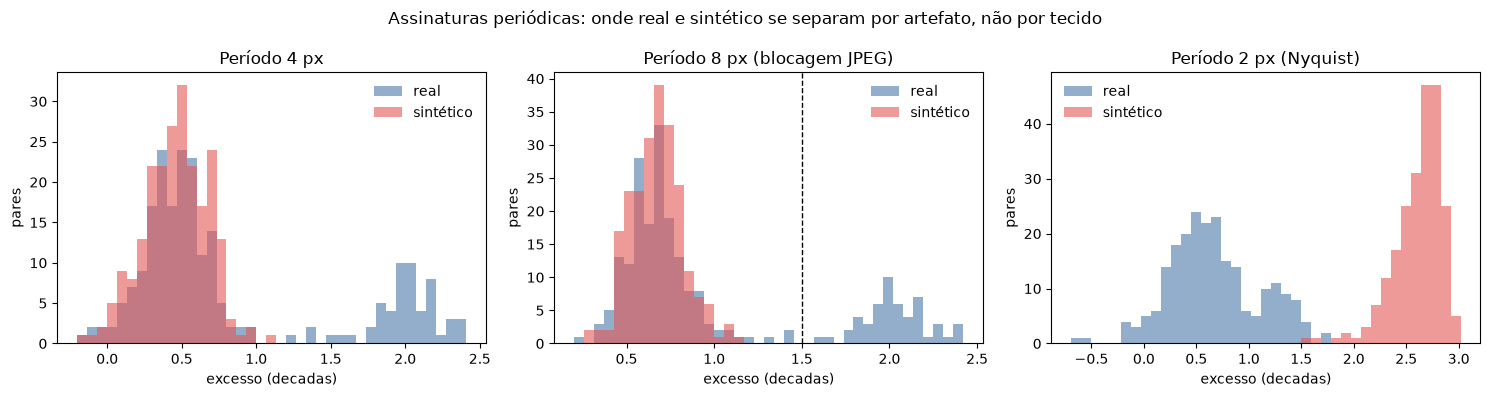

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (r, s, title) in zip(axes, [
    ("harmonic_4px_real", "harmonic_4px_syn", "Período 4 px"),
    ("harmonic_8px_real", "harmonic_8px_syn", "Período 8 px (blocagem JPEG)"),
    ("nyquist_excess_real", "nyquist_excess_syn", "Período 2 px (Nyquist)"),
]):
    if r not in qc or s not in qc:
        ax.set_visible(False)
        continue
    bins = np.linspace(min(qc[r].min(), qc[s].min()), max(qc[r].max(), qc[s].max()), 40)
    ax.hist(qc[r], bins=bins, alpha=0.6, label="real", color="#4C78A8")
    ax.hist(qc[s], bins=bins, alpha=0.6, label="sintético", color="#E45756")
    ax.set(title=title, xlabel="excesso (decadas)", ylabel="pares")
    ax.legend(frameon=False)
axes[1].axvline(1.5, color="k", ls="--", lw=1)
fig.suptitle("Assinaturas periódicas: onde real e sintético se separam por artefato, não por tecido")
fig.tight_layout()

## 4. Os conjuntos, lado a lado

Um par, todos os conjuntos, com recorte de 96 px para ver a escala fina. É aqui que
a alternância de 2 px do sintético fica visível a olho, e onde se vê que o bicúbico
erra na direção oposta.

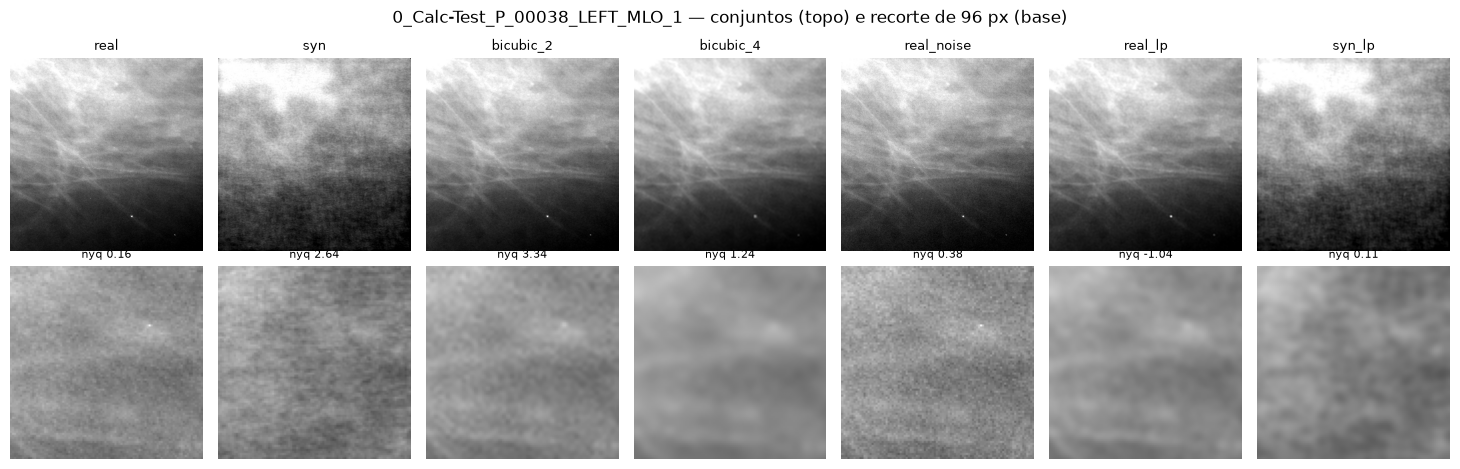

In [7]:
derived = pipeline.load_derived(cfg)
row = man.iloc[0]
real, syn = tio.load_pair(row)
sets, _ = tio.make_sets(real, syn, cfg["common"], cfg["controls"], derived["noise_sigma"],
                        np.random.default_rng(0))
show = ["real", "syn", "bicubic_2", "bicubic_4", "real_noise", "real_lp", "syn_lp"]
lo, hi = np.percentile(real, (1, 99))
c = slice(208, 304)
fig, axes = plt.subplots(2, len(show), figsize=(2.1 * len(show), 4.8))
for j, name in enumerate(show):
    t = sets[name]
    axes[0, j].imshow(t, cmap="gray", vmin=lo, vmax=hi)
    axes[0, j].set_title(name, fontsize=9)
    axes[1, j].imshow(t[c, c], cmap="gray", vmin=lo, vmax=hi)
    nyq = tspec.nyquist_excess(t)[0]
    axes[1, j].set_title(f"nyq {nyq:.2f}", fontsize=8)
    for ax in (axes[0, j], axes[1, j]):
        ax.axis("off")
axes[1, 0].set_ylabel("recorte 96 px")
fig.suptitle(f"{row.pair_id} — conjuntos (topo) e recorte de 96 px (base)")
fig.tight_layout()

## 5. Pares extremos — inspeção obrigatória

Correlação baixa **não** significa pareamento quebrado (o pareamento é por nome e
fecha 225/225); significa que o modelo se afastou da anatomia. E correlação alta não
significa sucesso: veja no par de maior correlação se as microcalcificações
sobreviveram — elas são o achado clínico e a correlação de Pearson, dominada pelo
gradiente de espessura, não as enxerga.

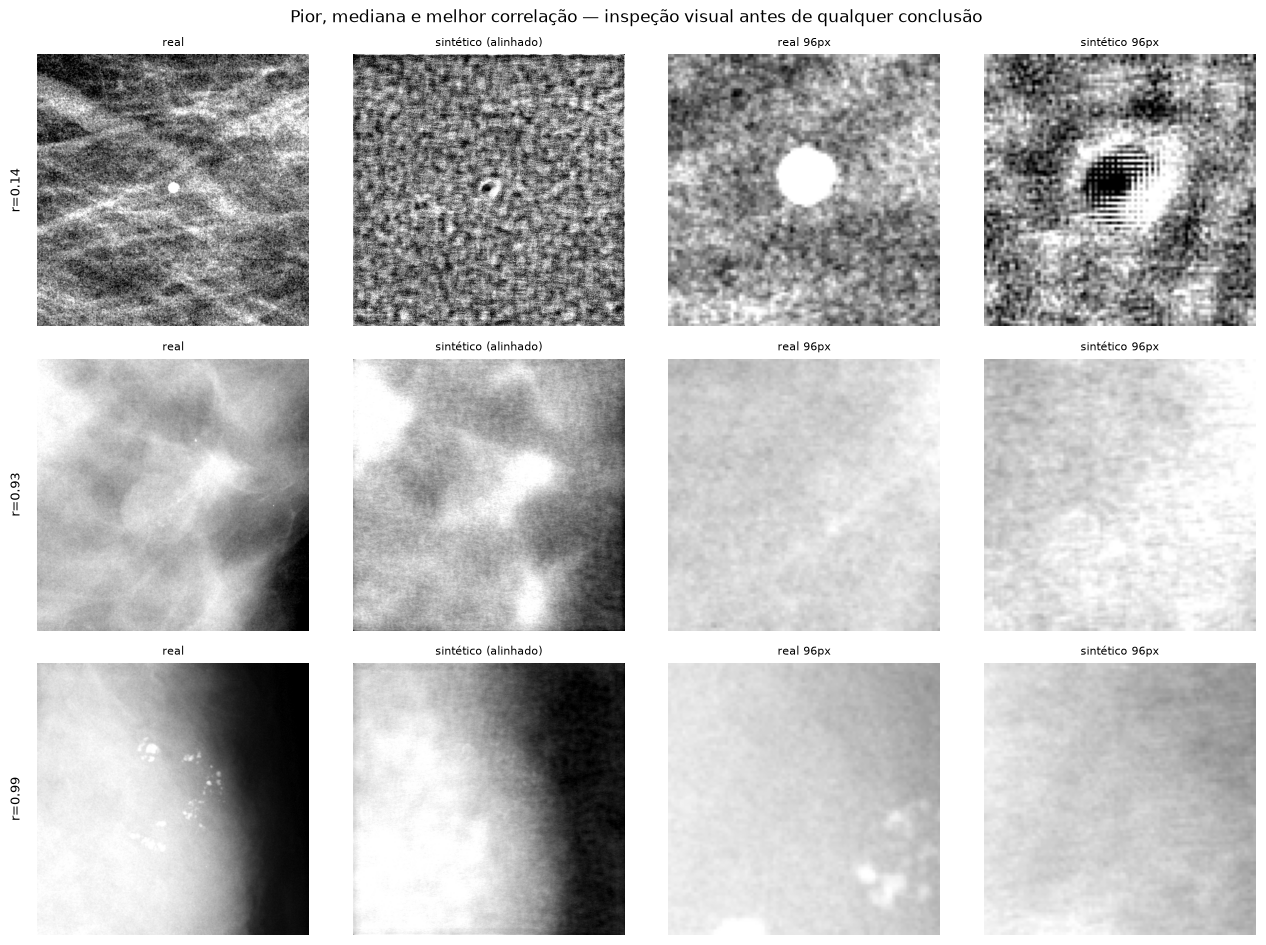

In [8]:
order = qc["corr"].sort_values()
picks = [order.index[0], order.index[len(order) // 2], order.index[-1]]
fig, axes = plt.subplots(len(picks), 4, figsize=(13, 3.2 * len(picks)))
for i, pid in enumerate(picks):
    r_row = man[man.pair_id == pid].iloc[0]
    real, syn = tio.load_pair(r_row)
    syn_al, _ = tio.affine_align(real, syn)
    lo, hi = np.percentile(real, (1, 99))
    for ax, (img, t) in zip(axes[i], [(real, "real"), (syn_al, "sintético (alinhado)"),
                                      (real[c, c], "real 96px"), (syn_al[c, c], "sintético 96px")]):
        ax.imshow(img, cmap="gray", vmin=lo, vmax=hi)
        ax.set_title(t, fontsize=8)
        ax.axis("off")
    axes[i, 0].text(-0.1, 0.5, f"r={qc.loc[pid, 'corr']:.2f}", transform=axes[i, 0].transAxes,
                    rotation=90, va="center", fontsize=9)
fig.suptitle("Pior, mediana e melhor correlação — inspeção visual antes de qualquer conclusão")
fig.tight_layout()

## 6. Flags e constantes derivadas

Nenhuma ROI foi removida. As flags abaixo alimentam a análise de sensibilidade do
notebook 03 (resultados com e sem as ROIs flagadas).

In [9]:
flags = pd.DataFrame({
    "jpeg_blocking (real, >1,5 dec)": [(qc["harmonic_8px_real"] > 1.5).sum()],
    "zero_frac > 1 %": [(qc["zero_frac_real"] > 0.01).sum()],
    "corr < 0,85": [(qc["corr"] < 0.85).sum()],
    "near_constant": [qc["near_constant"].sum()],
}, index=["n ROIs"]).T
print(flags.to_string())
print("\nconstantes derivadas do conjunto REAL:")
for k, v in derived.items():
    print(f"  {k}: {v}")

                                n ROIs
jpeg_blocking (real, >1,5 dec)    52.0
zero_frac > 1 %                   24.0
corr < 0,85                       33.0
near_constant                      0.0

constantes derivadas do conjunto REAL:
  noise_sigma: 0.012587718052914587
  gradient_threshold: 0.09572385511738275
  glcm_quant_lo: 0.0
  glcm_quant_hi: 0.8227970004081726
  n_pairs: 225
  config_hash: cab42bff5d31
